In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = Path("../../experiments/t2_beyond_baseline")
bucket = pd.read_csv(results_dir / "t2_bucket.csv")
saturation = pd.read_csv(results_dir / "t2_saturation.csv")

bucket_order = ["<=2 d", "2-5.7 d", "5.7-13 d", ">=13 d"]
arm_order = ["exp07_hann0p3_fbwd", "exp07_hann0p3_off", "untrained", "features_only",
             "amplitude_only"]
baseline_days = float(saturation["baseline_days"].iloc[0]) # 16 * 256 * 2 min, the model input baseline

In [2]:
cell = bucket[bucket["arm_set"].isin(["mu", "amplitude_only", "features_only"])
              & bucket["readout"].isin(["mean", "-"])
              & (bucket["transform"] == "log10")
              & (bucket["fit_scope"] == "global")
              & (bucket["bucket"] != "all")]

per_bucket = cell.groupby(["family", "bucket"], observed=True).agg(
    r2=("r2", "mean"), spearman=("spearman", "mean"), bias=("bias", "mean")).reset_index()

panels = {}
for metric in ["r2", "spearman", "bias"]:
    panels[metric] = per_bucket.pivot(index="family", columns="bucket",
                                      values=metric).reindex(arm_order)[bucket_order]

pd.concat(panels, axis=1).round(3)

r2                          spearman                   \
bucket              <=2 d 2-5.7 d 5.7-13 d  >=13 d    <=2 d 2-5.7 d 5.7-13 d   
family                                                                         
exp07_hann0p3_fbwd  0.154  -1.870   -5.630 -58.635    0.795   0.393    0.173   
exp07_hann0p3_off  -0.285  -1.830  -10.144 -72.680    0.756   0.177    0.114   
untrained          -0.802  -2.467  -18.044 -86.753    0.666   0.079    0.154   
features_only       0.199  -1.870   -6.522 -55.022    0.744   0.537    0.016   
amplitude_only     -2.111  -4.668  -29.487 -92.511    0.199  -0.019    0.270   

                            bias                          
bucket             >=13 d  <=2 d 2-5.7 d 5.7-13 d >=13 d  
family                                                    
exp07_hann0p3_fbwd -0.080  0.149   0.108   -0.189 -0.489  
exp07_hann0p3_off   0.077  0.246   0.061   -0.269 -0.550  
untrained           0.101  0.352  -0.017   -0.362 -0.586  
features_only      -0.112  0.148   0.034   -0.106 -0.453  
amplitude_only      0.335  0.505  -0.151   -0.475 -0.625

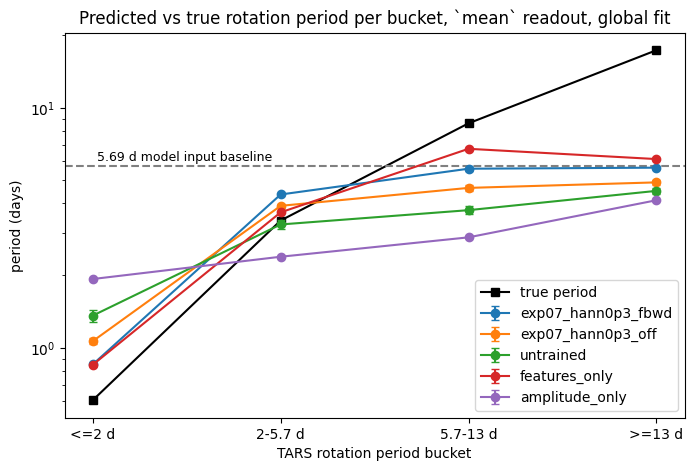

In [3]:
positions = np.arange(len(bucket_order))
truth = saturation.drop_duplicates("bucket").set_index("bucket").reindex(bucket_order)

plt.figure(figsize=(8, 5))
plt.plot(positions, truth["truth_days"], marker="s", color="black", label="true period")
for family in arm_order:
    rows = saturation[saturation["family"] == family].set_index("bucket").reindex(bucket_order)
    plt.errorbar(positions, rows["pred_days_mean"], yerr=rows["pred_days_sd"].fillna(0),
                 marker="o", capsize=3, label=family)
plt.axhline(baseline_days, linestyle="--", color="gray")
plt.text(0.02, baseline_days * 1.05, "5.69 d model input baseline", fontsize=9)
plt.yscale("log")
plt.xticks(positions, bucket_order)
plt.xlabel("TARS rotation period bucket")
plt.ylabel("period (days)")
plt.title("Predicted vs true rotation period per bucket, `mean` readout, global fit")
plt.legend()
plt.show()